In this first example we run the simulation once with default values. If we run it more times you will see that with both p-values at 0.5 and the locations being aud_max at 50, Kaia at 60 and pentagon at 30, about 1/3 of the times the simulation is run, Alex ends up at Pentagon and 2/3 at Kaia.

In [8]:
from walking.simulation import Simulation
from walking.environment import Environment

env = Environment()
sim = Simulation(env)

print(sim.run_once())

['kaia', 182, 878]


In this next piece of code we simulate 1000 times for each combinations for p_kaia and p_pentagon and we see that it doesn't vary much. All of them as long as the distance is what I set the to originally are very similar in value. This is probably because the distance from aud_max is way more significant. there is already a 2/3 possibility that Alex walks to kaia in the first place, and when first here. maybe goes back and forth a little, but on average should end up stepping on Kaia multiple times once here increasing the chances of staying here over Pentagon. We can see an overall slight trend in the data though, as higher values for p_kaia increases the probability of staying there slightly.

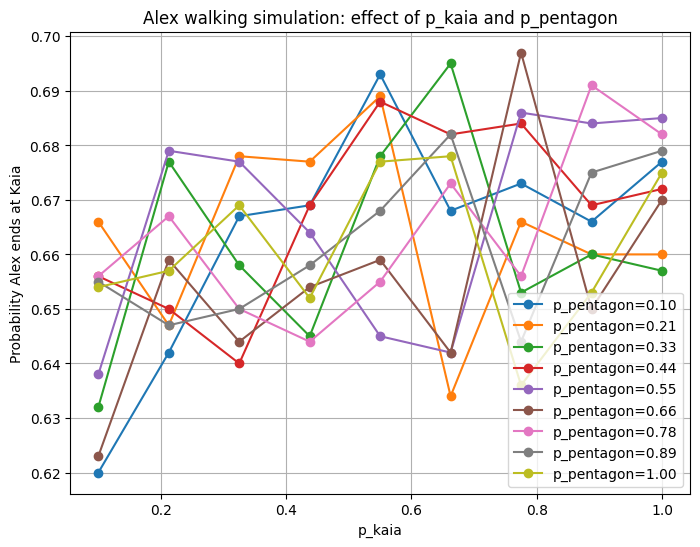

In [ ]:
# Explore how p_kaia and p_pentagon affect where Alex ends up
from walking.environment import Environment
from walking.simulation import Simulation
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n_runs = 1000 # Run the simulation 1000 times
p_values = np.linspace(0.1, 1, 9)

results = {}

# Loop through all combinations of p_values
for p_pentagon in p_values:
    for p_kaia in p_values:
        pentagon_count = 0
        kaia_count = 0
        steps_list = []
        seconds_list = []

        for i in range(n_runs):
            env = Environment()
            sim = Simulation(env)
            result = sim.run_once(
                step_chance=0.2,
                east_weight=0.5,
                p_pentagon=p_pentagon,
                p_kaia=p_kaia
            )

            place, steps, seconds = result
            steps_list.append(steps)
            seconds_list.append(seconds)

            if place == "pentagon":
                pentagon_count += 1
            elif place == "kaia":
                kaia_count += 1

        results[(p_pentagon, p_kaia)] = {
            "pentagon_prob": pentagon_count / n_runs,
            "kaia_prob": kaia_count / n_runs,
            "avg_steps": np.mean(steps_list),
            "avg_seconds": np.mean(seconds_list)
        }

# Example plot: probability of ending at Kaia
plt.figure(figsize=(8,6))
for p_pentagon in p_values:
    kaia_probs = [results[(p_pentagon, p_kaia)]["kaia_prob"] for p_kaia in p_values]
    plt.plot(p_values, kaia_probs, marker='o', label=f"p_pentagon={p_pentagon:.2f}")

plt.xlabel("p_kaia")
plt.ylabel("Probability Alex ends at Kaia")
plt.title("Alex walking simulation: effect of p_kaia and p_pentagon")
plt.grid()
plt.legend()
plt.show()
